# Presentation figures (260616)

Dataset: `data/embeddings/proof_benchmarked_260505/var-ring-sym_phi-0.95_cpl-0.4/M10_T500_I6`.

Plots: MTS heatmap; MPI heatmaps for `cov_EmpiricalCovariance`, `spearmanr`, `mi_kraskov_NN-4`; unravel off-diagonals to 1D barcode; two-SPI scatter.

In [4]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import spearmanr, zscore
from sklearn.preprocessing import robust_scale

# ---- tweakable knobs ----
dpi = 500
save_fmt = "svg"  # "png" or "svg"
use_latex = True

DATASET = Path("../../data/embeddings/proof_benchmarked90_260603/var-phi-0.95_cpl-0.4/M10_T500_I9")
output_dir = Path("figures4")
output_dir.mkdir(parents=True, exist_ok=True)

# Presentation-tuned rcParams. Override individually below if needed.
sns.set_theme(
    style="white",
    rc={
        "text.usetex": use_latex,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 22,
        "axes.titlesize": 22,
        "axes.labelsize": 22,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 22,
        "legend.title_fontsize": 22,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "savefig.transparent": True,
    },
)

# Load meta once (for directedness + labels per SPI)
with (DATASET / "meta.json").open() as f:
    META = json.load(f)
SPI_META = {e["name"]: e for e in META.get("pyspi", {}).get("spis", []) if e.get("name")}
ARCHIVE = DATASET / "spi_mpis.npz"
TAG = f"{DATASET.parent.name}_{DATASET.name}"
TAG

'var-phi-0.95_cpl-0.4_M10_T500_I9'

## MTS heatmap

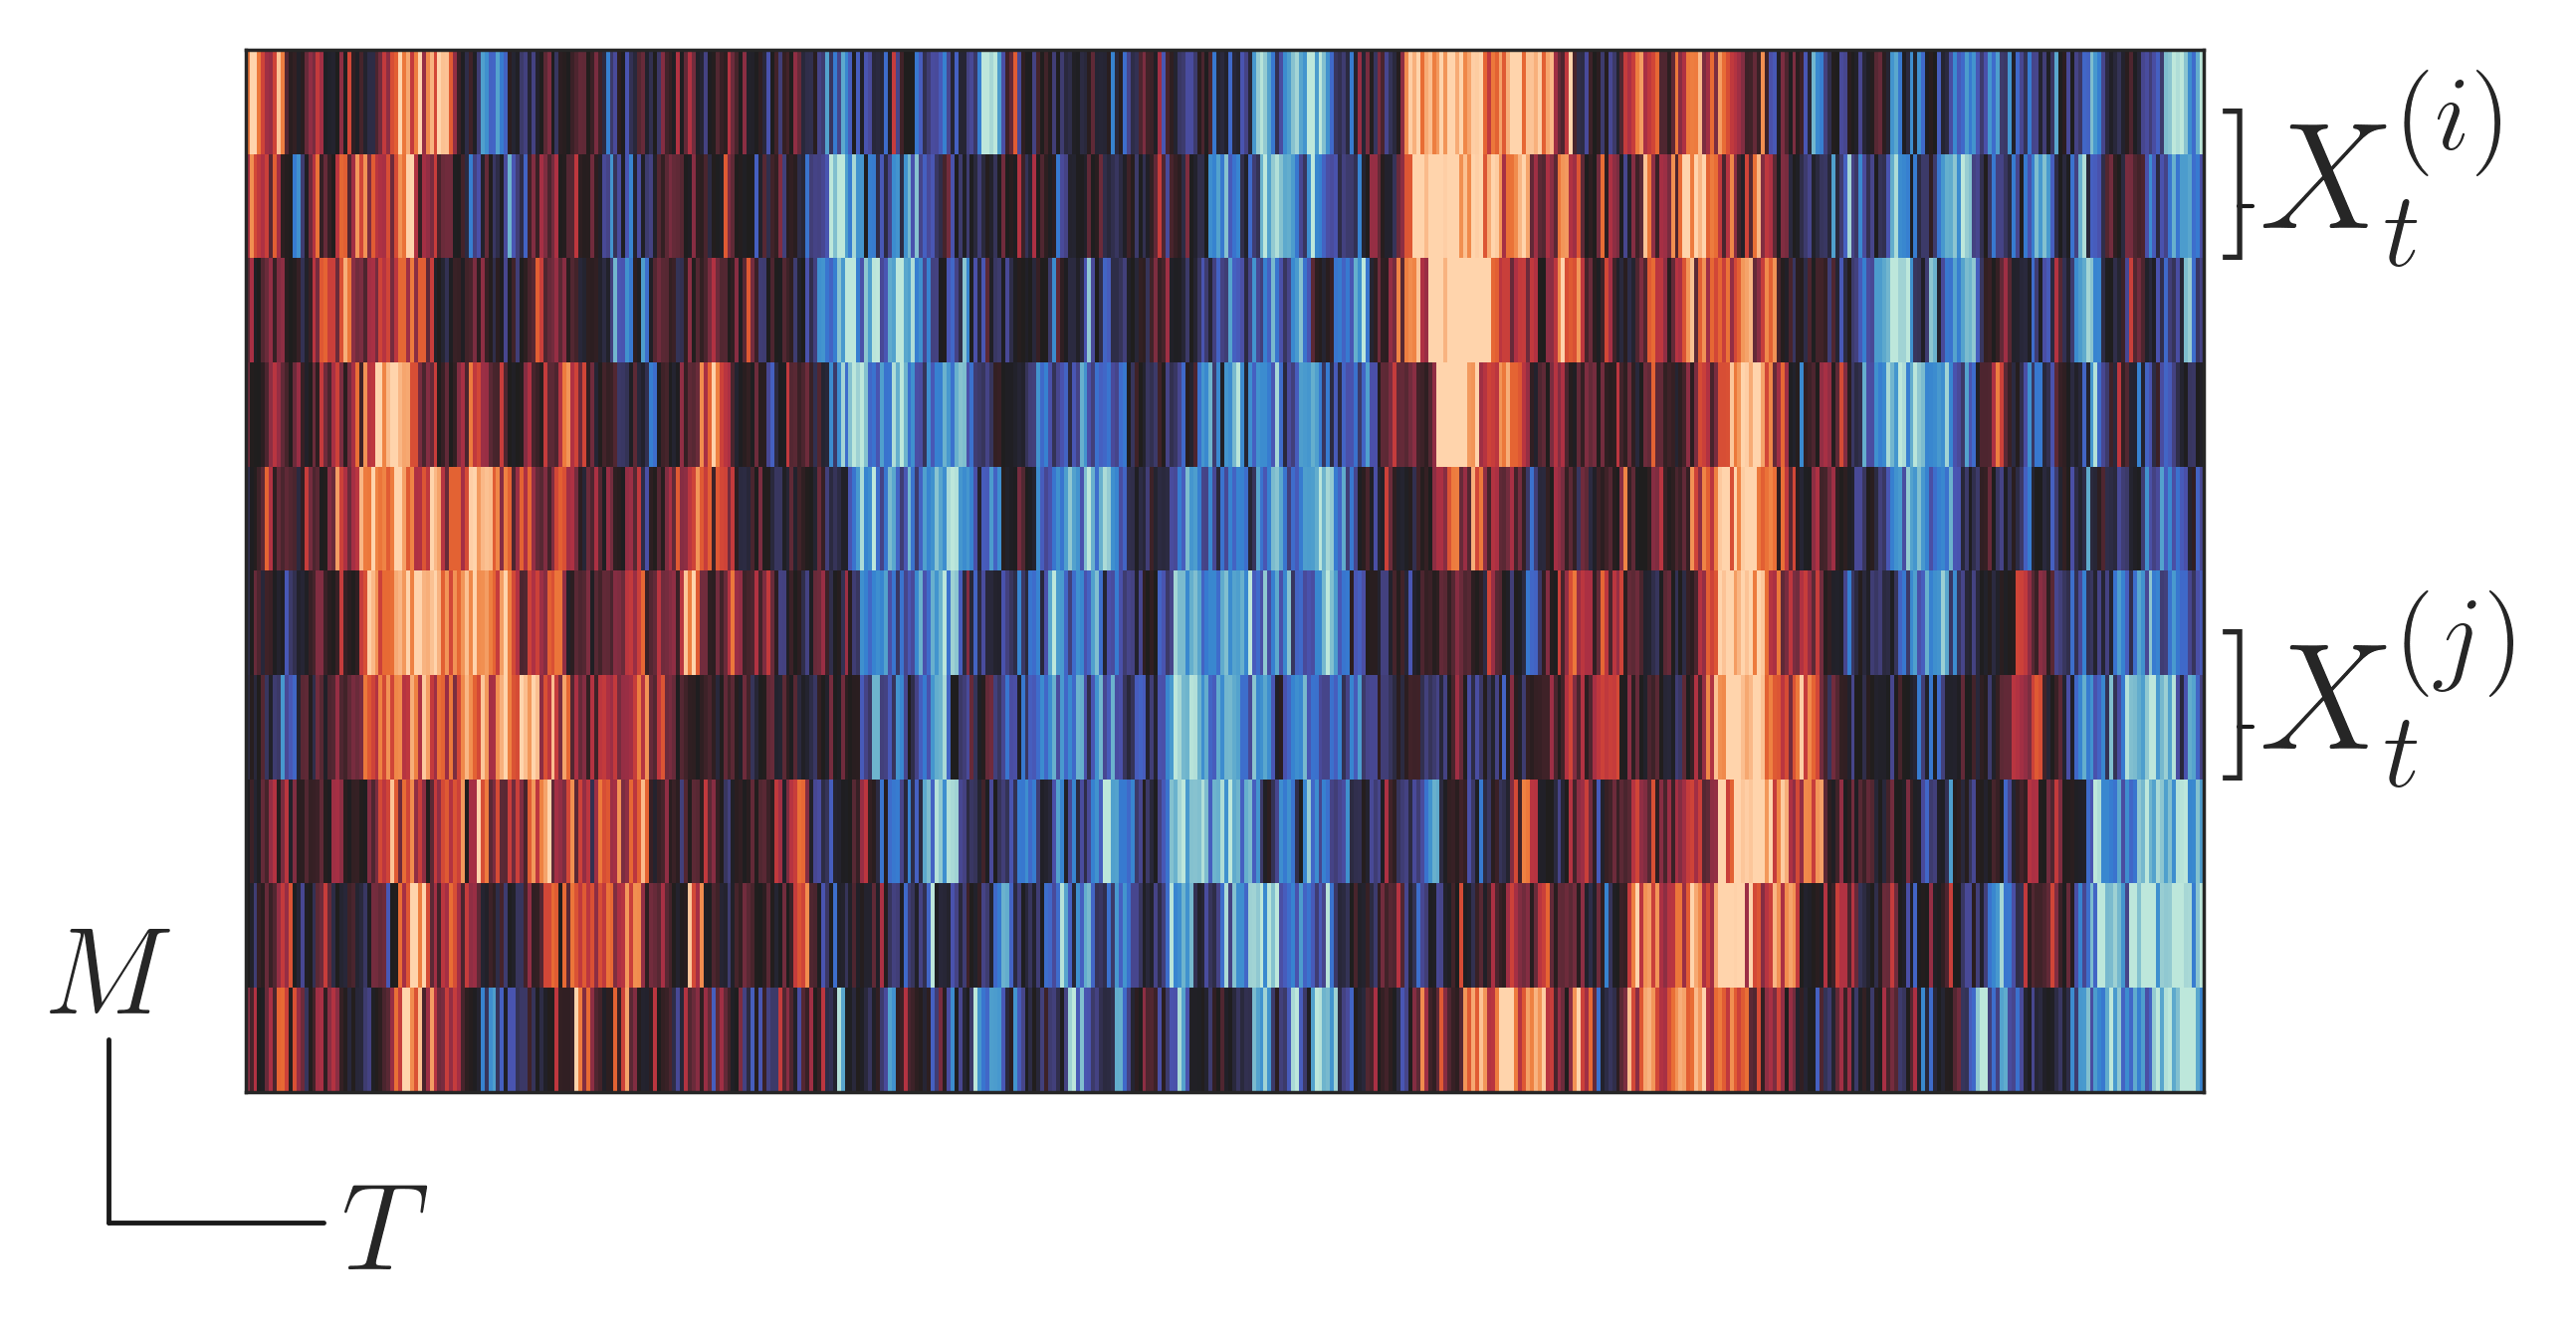

In [5]:
# ---- tweakable ----
mts_cmap = "icefire"
mts_vmin, mts_vmax = -2.0, 2.0
mts_figsize = (5, 2.5)

data = np.load(DATASET / "timeseries.npy").astype(float)
if data.shape[0] > data.shape[1]:  # ensure (M, T)
    data = data.T
scaled = zscore(data, axis=1, nan_policy="omit")
scaled = np.nan_to_num(scaled, nan=0.0, posinf=0.0, neginf=0.0)

fig, ax = plt.subplots(figsize=mts_figsize, dpi=dpi)
ax.pcolormesh(scaled, shading="flat", vmin=mts_vmin, vmax=mts_vmax,
              cmap=sns.color_palette(mts_cmap, as_cmap=True))
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_linewidth(0.5)  

# axes-fraction coords: (0,0)=bottom-left. Move each freely.
# ax.text(-0.055, 0.00, r"$\uparrow$", transform=ax.transAxes, clip_on=False)
ax.text(-0.1, 0.075, r"$M$", transform=ax.transAxes, clip_on=False, fontsize=18)
# ax.text(-0.03, -0.09, r"$\rightarrow$", transform=ax.transAxes, clip_on=False)
ax.text(0.05, -0.17, r"$T$", transform=ax.transAxes, clip_on=False, fontsize=18)

ax.text(1.03, 0.828, r"$X_t^{(i)}$", transform=ax.transAxes, clip_on=False)  #8
ax.text(1.03, 0.328, r"$X_t^{(j)}$", transform=ax.transAxes, clip_on=False)  #3

ax.text(1.01, 0.335, r"$\Biggr]$", transform=ax.transAxes, clip_on=False)  #3
# ax.text(1.01, 0.335, r"$\Biggr\}$", transform=ax.transAxes, clip_on=False)  #3
ax.plot([1.018, 1.025], [0.35, 0.35], transform=ax.transAxes, clip_on=False, color="k", lw=0.6)

ax.text(1.01, 0.835, r"$\Biggr]$", transform=ax.transAxes, clip_on=False)  #8
ax.plot([1.018, 1.025], [0.85, 0.85], transform=ax.transAxes, clip_on=False, color="k", lw=0.6)

hor_line = -0.125
vert_line = -0.07
# lines: ax.plot([x0,x1],[y0,y1]). vertical then horizontal segment near corner.
ax.plot([vert_line, vert_line], [hor_line, 0.05], transform=ax.transAxes, clip_on=False, color="k", lw=0.7)
ax.plot([vert_line, 0.04], [hor_line, hor_line], transform=ax.transAxes, clip_on=False, color="k", lw=0.7)

fig.tight_layout(pad=0.05)
fig.savefig(output_dir / f"mts_heatmap_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight", pad_inches=0)
plt.show()

## Individual channel

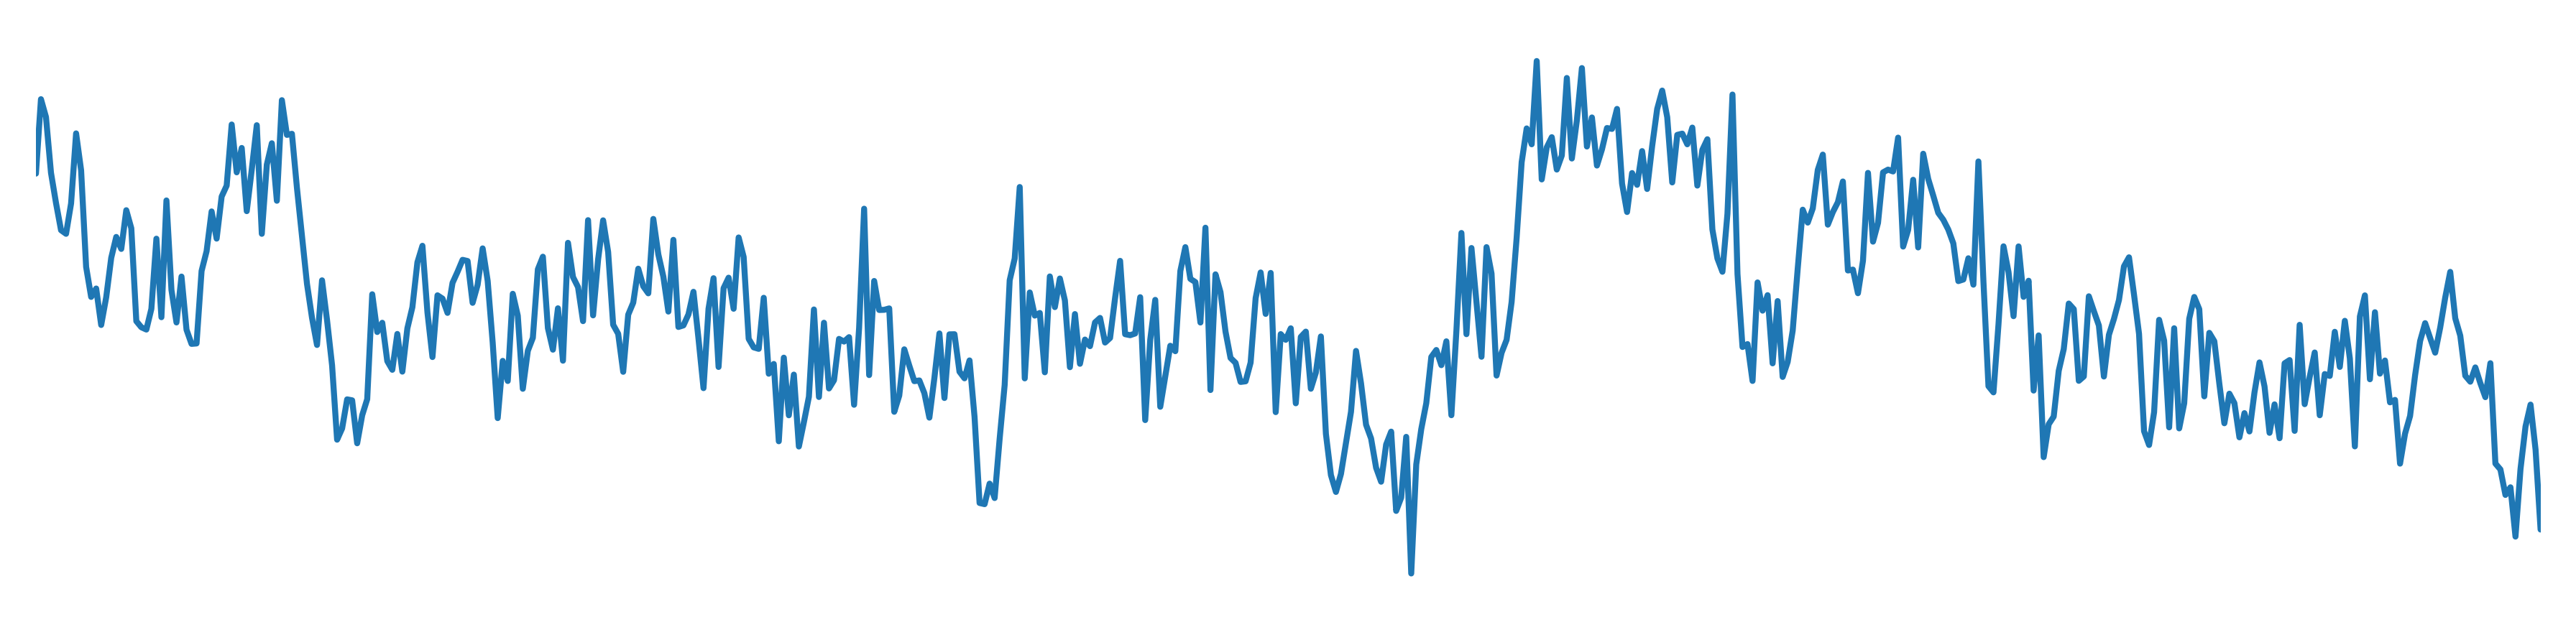

array([ 1.47018612e+00,  2.27200151e+00,  2.07957864e+00,  1.47838855e+00,
        1.15265107e+00,  8.60634686e-01,  8.21547867e-01,  1.14854777e+00,
        1.90337694e+00,  1.50552559e+00,  4.64479805e-01,  1.41653137e-01,
        2.32166992e-01, -1.60811512e-01,  1.38000713e-01,  5.62665523e-01,
        7.87762166e-01,  6.58656717e-01,  1.07584572e+00,  8.81263972e-01,
       -1.19341044e-01, -1.85240640e-01, -2.10070996e-01,  1.34026896e-02,
        7.68947364e-01, -7.70397024e-02,  1.18091142e+00,  2.16492609e-01,
       -1.33700012e-01,  3.60767038e-01, -2.11894868e-01, -3.64340483e-01,
       -3.59825014e-01,  4.20996220e-01,  6.33782209e-01,  1.06278348e+00,
        7.69587279e-01,  1.22288978e+00,  1.34065092e+00,  1.99907339e+00,
        1.48375917e+00,  1.74650300e+00,  1.06567991e+00,  1.51448035e+00,
        1.99156678e+00,  8.21466983e-01,  1.56688690e+00,  1.79710734e+00,
        1.17769992e+00,  2.26123285e+00,  1.88723517e+00,  1.89908278e+00,
        1.31661868e+00,  

In [6]:
def plot_channel(channel, *, clip=None, color="#1f77b4", figsize=(7, 1.6), linewidth=1.2):
    """Plot a single z-scored channel as a 1D time series line."""
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    if not 0 <= channel < M:
        raise IndexError(f"channel {channel} out of range for M={M}")
    series = zscore(raw, axis=1, nan_policy="omit")[channel]
    series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
    if clip is not None:
        series = series[clip[0]:clip[1]]
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.plot(np.arange(series.size), series, color=color, linewidth=linewidth)
    # ax.axhline(0.0, color="black", linewidth=0.5, alpha=0.5)
    ax.set_xlim(0, series.size - 1)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    fig.tight_layout(pad=0.05)
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel-{channel}{clip_tag}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return series

plot_channel(9)
# plot_channel(0, clip=(100, 300))

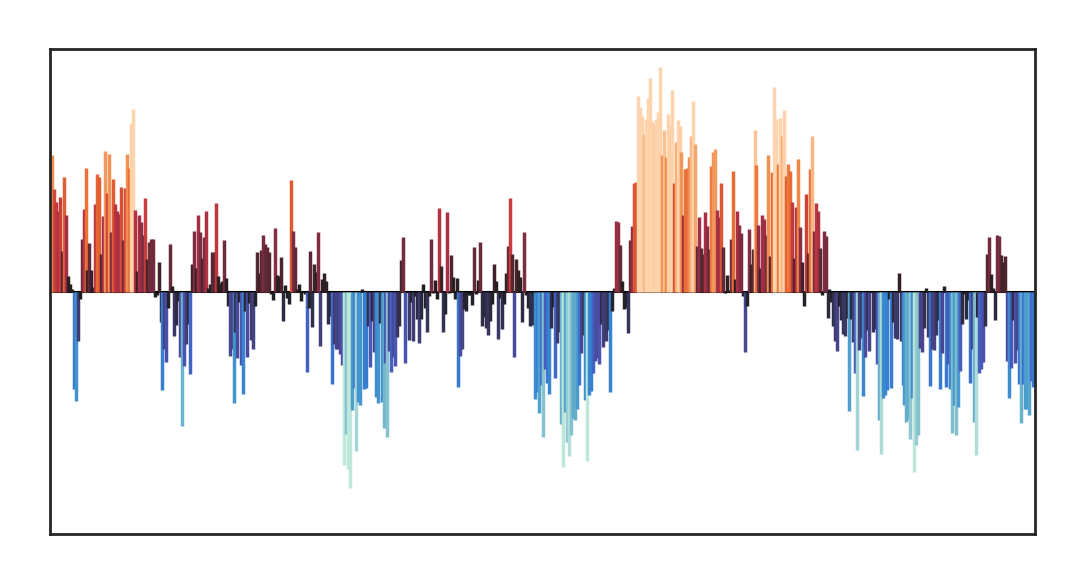

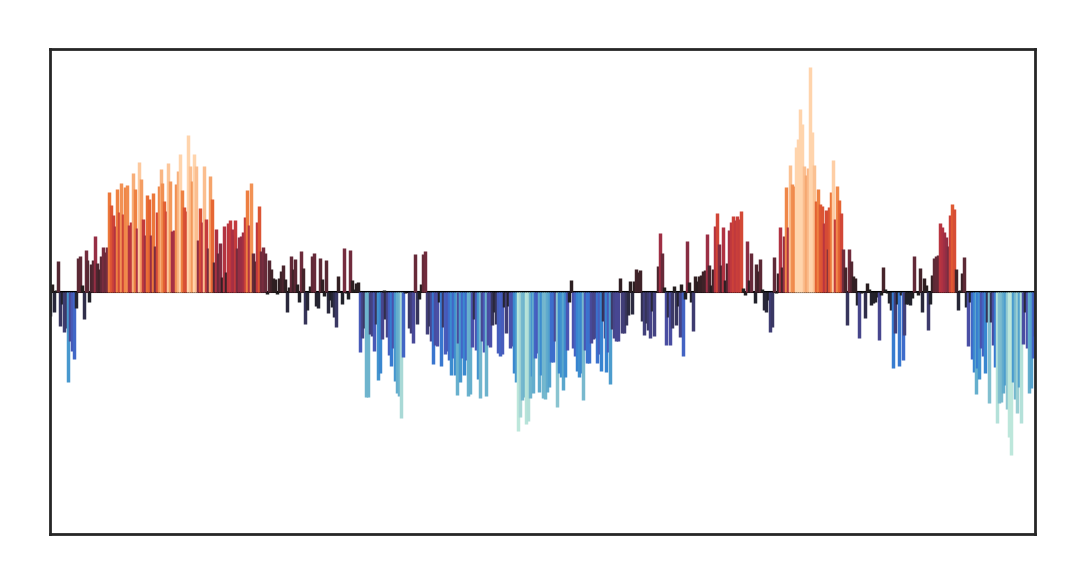

array([-3.57150108e-01,  1.15930660e-01, -3.10191870e-01,  2.78647737e-02,
        4.59896831e-01, -5.13972521e-01, -1.78258107e-01, -5.93225538e-01,
       -5.38400590e-01, -1.33937084e+00, -7.36673474e-01, -8.88162433e-01,
       -9.99946176e-01, -2.41795183e-01,  4.95625464e-01,  5.27008770e-01,
        1.04716866e-01, -4.04832661e-01,  6.26468179e-01,  4.71120624e-01,
       -1.53217108e-01,  4.16610478e-01,  4.67720626e-01,  8.28114567e-01,
        4.28623645e-01,  3.43632130e-01,  5.25922535e-01,  6.65979621e-01,
        5.85081158e-01,  6.58360777e-01,  1.48045325e+00,  1.29253113e+00,
        1.14129936e+00,  9.69019887e-01,  1.52697789e+00,  1.18969750e+00,
        1.62222993e+00,  1.16020560e+00,  1.55080819e+00,  1.59137415e+00,
        9.95645520e-01,  1.04225385e+00,  1.76595580e+00,  1.52977395e+00,
        9.49251291e-01,  1.93253254e+00,  1.67663776e+00,  1.07618725e+00,
        8.46161244e-01,  1.43666720e+00,  1.37429845e+00,  8.37490496e-01,
        1.47105491e+00,  

In [7]:
def plot_channel_stem(channel, *, clip=None, cmap="icefire", vmin=-2.0, vmax=2.0,
                      figsize=(2, 1), linewidth=0.5, markersize=0.0):
    """Stem plot of a z-scored channel; each stem + head is colored by its value
    under the MTS-heatmap colormap (icefire, same vmin/vmax). Baseline y=0 centered."""
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    if not 0 <= channel < M:
        raise IndexError(f"channel {channel} out of range for M={M}")
    series = zscore(raw, axis=1, nan_policy="omit")[channel]
    series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
    if clip is not None:
        series = series[clip[0]:clip[1]]
    x = np.arange(series.size)
    cm = sns.color_palette(cmap, as_cmap=True)
    colors = cm(plt.Normalize(vmin, vmax)(series))  # per-sample color = heatmap color

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.axhline(0.0, color="black", linewidth=0.3, zorder=1)
    ax.vlines(x, 0.0, series, colors=colors, linewidth=linewidth, zorder=2)
    ax.scatter(x, series, s=markersize, c=colors, edgecolors="none",
               linewidths=0.5, zorder=3)
    m = max(np.abs(series).max() * 1.08, 1e-9)
    ax.set_xlim(0, series.size - 1)
    ax.set_ylim(-m, m)  # symmetric -> horizontal axis centered
    ax.set_xticks([]); ax.set_yticks([])
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    # ax.spines["left"].set_visible(False)
    # ax.spines["bottom"].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    # ax.spines["bottom"].set_position(("data", 0.0))  # move horizontal axis to y=0
    fig.tight_layout(pad=0.05)
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel-stem-{channel}{clip_tag}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return series

plot_channel_stem(8)
plot_channel_stem(3)
# plot_channel_stem(3, clip=(0,120))
# plot_channel_stem(8, clip=(0,120))

### Scatter of two channels $(i)$ vs $(j)$ from MTS

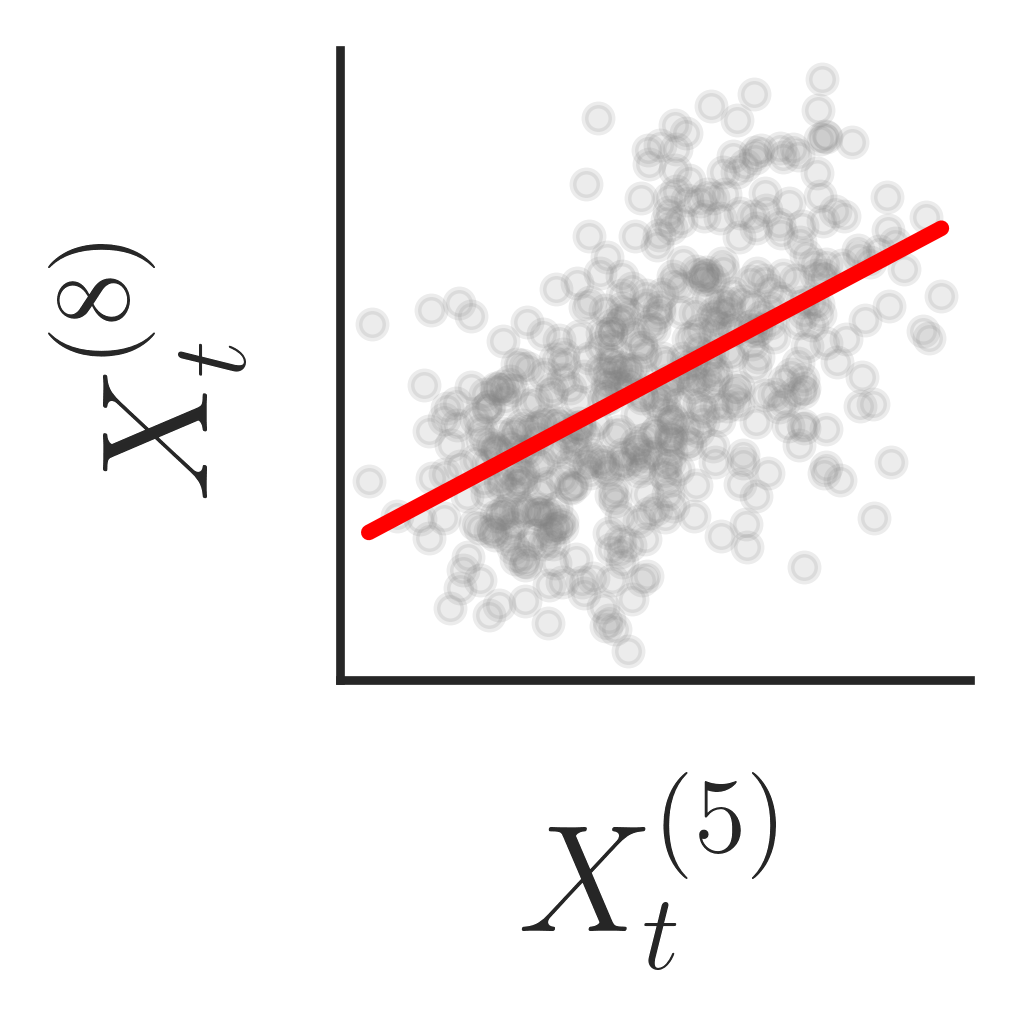

In [8]:
from scipy.stats import rankdata
from sklearn.feature_selection import mutual_info_regression


def plot_channel_scatter(channel_x, channel_y, *, metric="pearson", clip=None,
                         scatter_color="#1f77b4", reg_color="#d62728",
                         scatter_s=30, scatter_alpha=0.2, mi_neighbors=4,
                         figsize=(2.5, 2.5), label=True, dpi=dpi):
    """Scatter one z-scored channel against another in channel-channel space.

    metric:
      "pearson"  -> linear fit + r (linear association).
      "spearman" -> ranks both axes, linear fit in rank space + rho
                    (Spearman == Pearson on ranks).
      "mi"       -> raw scatter + LOWESS smoother that *tracks* the cloud, and
                    annotates the KSG mutual-information estimate. NOTE: the
                    curve is a nonparametric smoother, not "the MI"; MI is a
                    scalar dependence measure with no regression line.
    """
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    for c in (channel_x, channel_y):
        if not 0 <= c < M:
            raise IndexError(f"channel {c} out of range for M={M}")
    Z = zscore(raw, axis=1, nan_policy="omit")
    Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
    x = Z[channel_x]; y = Z[channel_y]
    if clip is not None:
        x = x[clip[0]:clip[1]]; y = y[clip[0]:clip[1]]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    xlab = rf"$X^{{({channel_x})}}_t$"; ylab = rf"$X^{{({channel_y})}}_t$"

    if metric == "pearson":
        stat = float(np.corrcoef(x, y)[0, 1])
        ax.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=reg_color, ci=None)
        label = rf"$r = {stat:.2f}$"

    elif metric == "spearman":
        rho = float(spearmanr(x, y).statistic)
        x, y = rankdata(x), rankdata(y)          # Spearman == Pearson on ranks
        ax.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=reg_color, ci=None)
        label = rf"$\rho = {rho:.2f}$"
        xlab = rf"$\mathrm{{rank}} [X^{{({channel_x})}}_t]$"
        ylab = rf"$\mathrm{{rank}} [X^{{({channel_y})}}_t]$"

    elif metric == "mi":
        mi = float(mutual_info_regression(
            x.reshape(-1, 1), y, n_neighbors=mi_neighbors, random_state=0)[0])
        ax.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=reg_color, lowess=True)
        label = rf"$\mathrm{{MI}} = {mi:.2f}$"

    else:
        raise ValueError(f"unknown metric {metric!r}; use 'pearson'|'spearman'|'mi'")

    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    if label == True:
        ax.text(0.03, 0.97, label, transform=ax.transAxes, ha="left", va="top")
    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticklabels([]); ax.set_yticklabels([])
    fig.tight_layout()
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel_scatter_{channel_x}_vs_{channel_y}_{metric}{clip_tag}_{TAG}.{save_fmt}",
                dpi=dpi, bbox_inches="tight")
    plt.show()

label = False
scatter_color="gray"
reg_color="red"
scatter_s=15
scatter_alpha=0.15

plot_channel_scatter(5, 8, metric="pearson", scatter_color=scatter_color, reg_color=reg_color,
                     scatter_s=scatter_s, scatter_alpha=scatter_alpha, label=label)
# plot_channel_scatter(5, 8, metric="spearman", scatter_color=scatter_color, reg_color=reg_color,
#                    scatter_s=scatter_s, scatter_alpha=scatter_alpha, label=label)
# plot_channel_scatter(5, 8, metric="mi", scatter_color=scatter_color, reg_color=reg_color,
#                    scatter_s=scatter_s, scatter_alpha=scatter_alpha, label=label)

## MPI heatmaps for `cov_EmpiricalCovariance`, `spearmanr`, `mi_kraskov_NN-4`

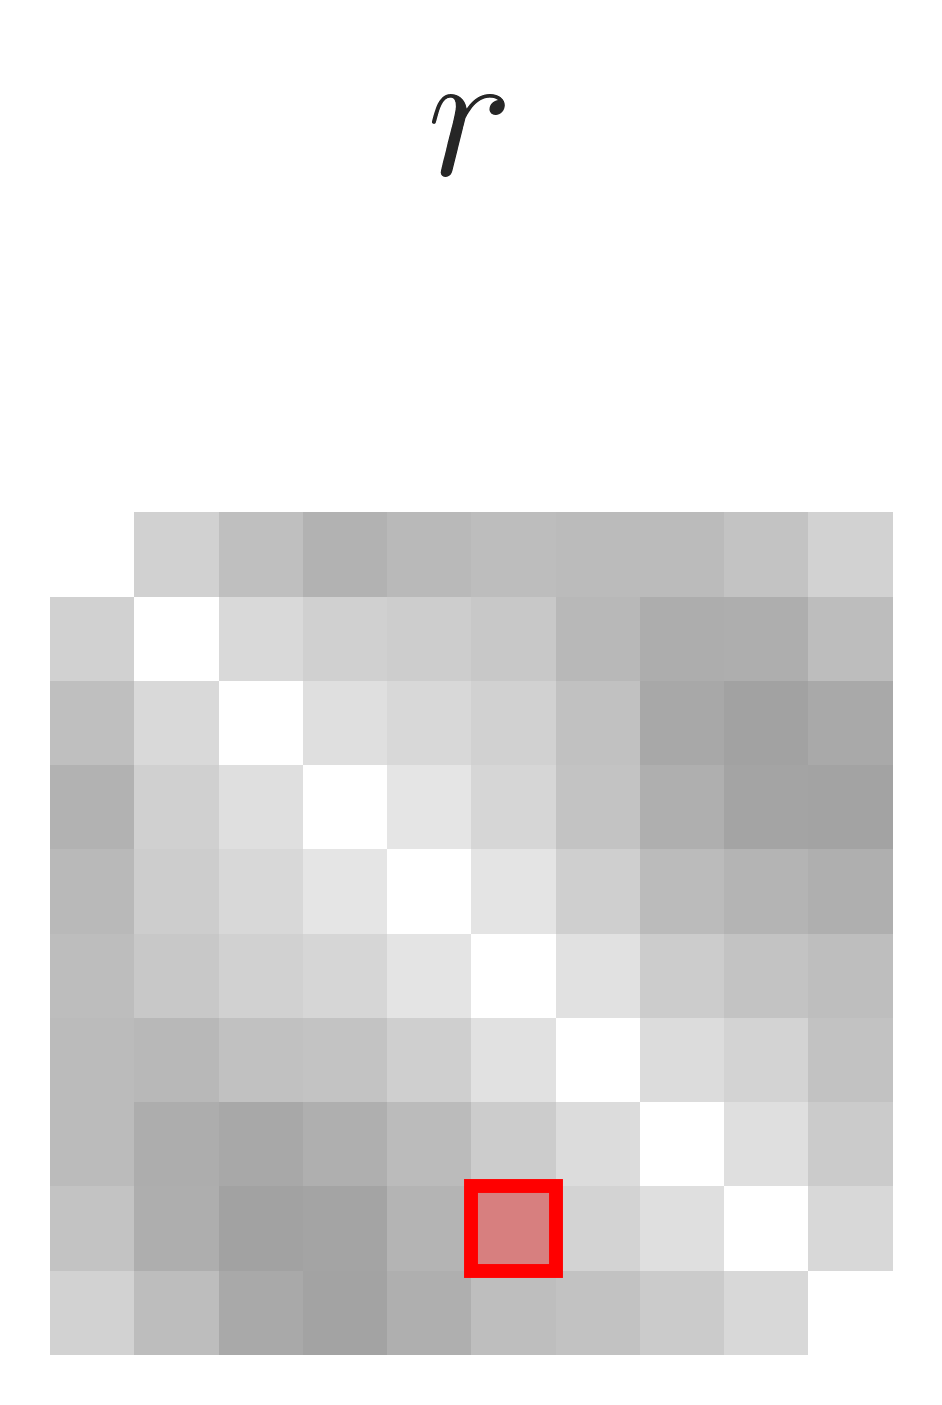

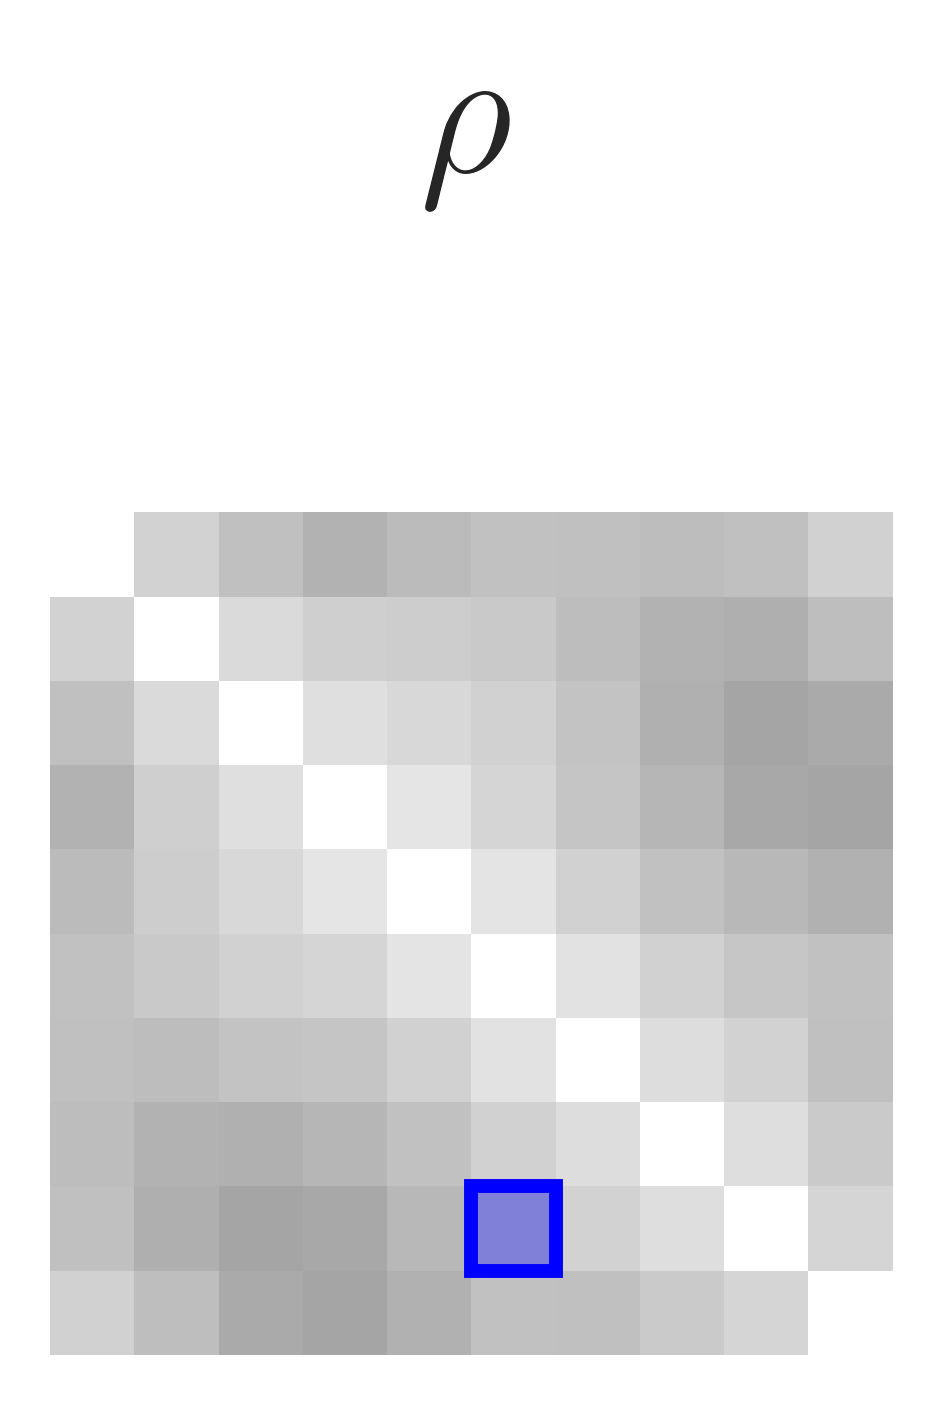

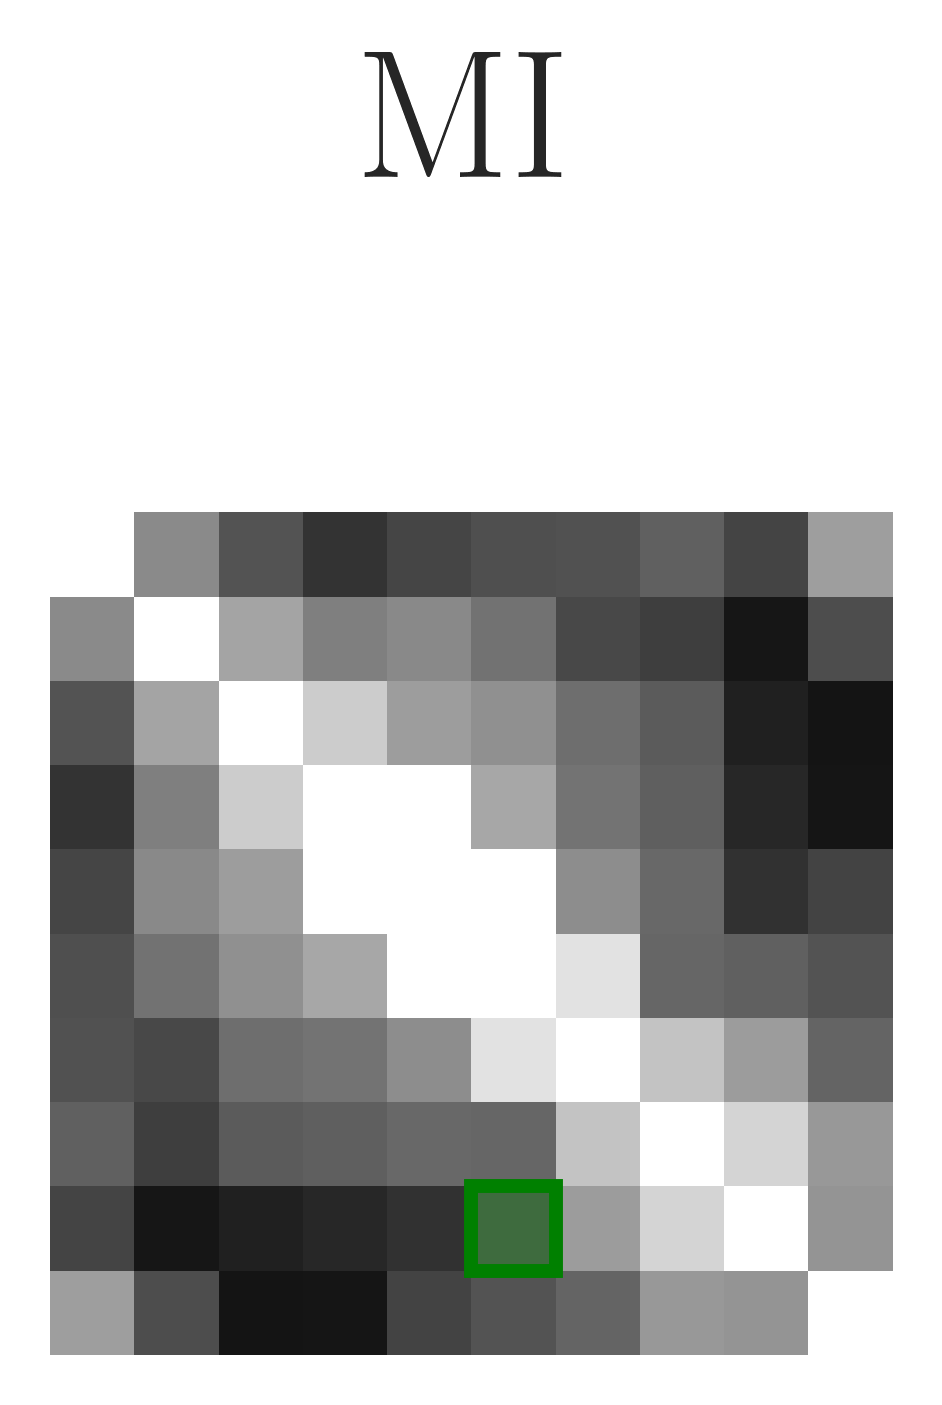

array([[0.        , 0.27288867, 0.1650159 , 0.10259833, 0.13800624,
        0.15780026, 0.16055476, 0.19080878, 0.1345704 , 0.31216234],
       [0.27288867, 0.        , 0.32479677, 0.25193179, 0.27136557,
        0.22675714, 0.14269885, 0.12285459, 0.04452537, 0.15371852],
       [0.1650159 , 0.32479677, 0.        , 0.40427035, 0.31151934,
        0.28622576, 0.21751154, 0.18067289, 0.06460355, 0.04097506],
       [0.10259833, 0.25193179, 0.40427035, 0.        , 0.50542451,
        0.33081084, 0.22775076, 0.18842397, 0.0784704 , 0.04203911],
       [0.13800624, 0.27136557, 0.31151934, 0.50542451, 0.        ,
        0.50425241, 0.28016732, 0.20692141, 0.09858999, 0.13372967],
       [0.15780026, 0.22675714, 0.28622576, 0.33081084, 0.50425241,
        0.        , 0.44727585, 0.20276357, 0.18975765, 0.16554309],
       [0.16055476, 0.14269885, 0.21751154, 0.22775076, 0.28016732,
        0.44727585, 0.        , 0.38657993, 0.30807971, 0.19833459],
       [0.19080878, 0.12285459, 0.1806728

In [41]:
def plot_mpi_heatmap(spi, *, title=None, show_title=False, cmap="gray",
                     vmin=None, vmax=None, center=None, mask_diagonal=False,
                     highlight=None, highlight_color="red", highlight_lw=2.0,
                     highlight_alpha=0.35, figsize=(3, 3), dpi=dpi):
    """Heatmap of one SPI's MPI matrix from ARCHIVE.

    spi:           SPI key in spi_mpis.npz (e.g. "cov_EmpiricalCovariance").
    title:         caption text; None -> use the spi name.
    show_title:    whether to draw the title.
    cmap:          any matplotlib/seaborn colormap.
    vmin/vmax/center: color bounds; None -> auto from data.
    mask_diagonal: NaN-out the diagonal (self-coupling) for the plot only.
    highlight:     cell(s) to mark. None -> none; a single (i, j) tuple uses
                   highlight_color; a dict {(i, j): color} sets a color per cell.
                   Each cell gets a translucent fill (highlight_alpha) + solid border.
    Returns the (unmasked) matrix.
    """
    if highlight is None:
        highlight = {}
    elif isinstance(highlight, tuple):
        highlight = {highlight: highlight_color}

    with np.load(ARCHIVE) as npz:
        mat = np.asarray(npz[spi], float)
    plot_mat = mat.copy()
    if mask_diagonal:
        np.fill_diagonal(plot_mat, np.nan)  # NaN cells transparent; skipped by auto vmin/vmax
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    sns.heatmap(plot_mat, cmap=cmap, vmin=vmin, vmax=vmax, center=center,
                square=True, xticklabels=False, yticklabels=False, cbar=False, ax=ax)
    ax.set_xlabel(None); ax.set_ylabel(None)
    for (i, j), c in highlight.items():  # cell (row i, col j) -> rectangle at x=j, y=i
        ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=mpl.colors.to_rgba(c, highlight_alpha),
                                   edgecolor=c, lw=highlight_lw, clip_on=False, zorder=5))
    if show_title:
        t = title if title is not None else spi
        fig.suptitle(t.replace("_", r"\_") if use_latex else t)
    fig.tight_layout()
    fig.savefig(output_dir / f"mpi_heatmap_{spi}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight", transparent=False)
    plt.show()
    return mat


# ---- tweakable: per-SPI cmap and color bounds. None -> auto from data. ----
SPIS_MPI = {
    # name:                    (cmap,   vmin,  vmax,  center,  title)
    "cov_EmpiricalCovariance": ("gray", -1.0,  1.0,   0.0,   r"$r$"),
    "spearmanr":               ("gray", -1.0,  1.0,   0.0,   r"$\rho$"),
    "mi_kraskov_NN-4":         ("gray", None,  None,  None,  r"$\mathrm{MI}$"),
}

mask_diagonal = True   # diagonal is self-coupling (max); exclude to avoid cmap bias
show_title = True     # toggle SPI name above each heatmap
cmap="gray"


# plot_mpi_heatmap("cov_EmpiricalCovariance", title=r"$r$", show_title=True,
#                 cmap=cmap,vmin=-1, vmax=1.0, center=0, mask_diagonal=mask_diagonal)

# plot_mpi_heatmap("spearmanr", title=r"$\rho$", show_title=True, 
#                 cmap=cmap, vmin=-1, vmax=1, center=0, mask_diagonal=mask_diagonal)

# plot_mpi_heatmap("mi_kraskov_NN-4", title=r"$\mathrm{MI}$", show_title=True, 
#                 cmap=cmap, vmin=0, vmax=None, center=None, mask_diagonal=mask_diagonal)

# highlight a cell, e.g. (i,j)=(2,8) red:
plot_mpi_heatmap("cov_EmpiricalCovariance", title=r"$r$", show_title=True, cmap=cmap,
                 vmin=-1, vmax=1, center=0, mask_diagonal=mask_diagonal,
                 highlight={(8, 5): "red"})

plot_mpi_heatmap("spearmanr", title=r"$\rho$", show_title=True, cmap=cmap,
                 vmin=-1, vmax=1, center=0, mask_diagonal=mask_diagonal,
                 highlight={(8, 5): "blue"})

plot_mpi_heatmap("mi_kraskov_NN-4", title=r"$\mathrm{MI}$", show_title=True, cmap=cmap,
                 vmin=0, vmax=None, center=None, mask_diagonal=mask_diagonal,
                 highlight={(8, 5): "green"})

## Unravel off-diagonals into a 1D vector heatmap ("barcode")

Always symmetrises each matrix (mean of upper and lower) and takes the lower-triangular off-diagonals.

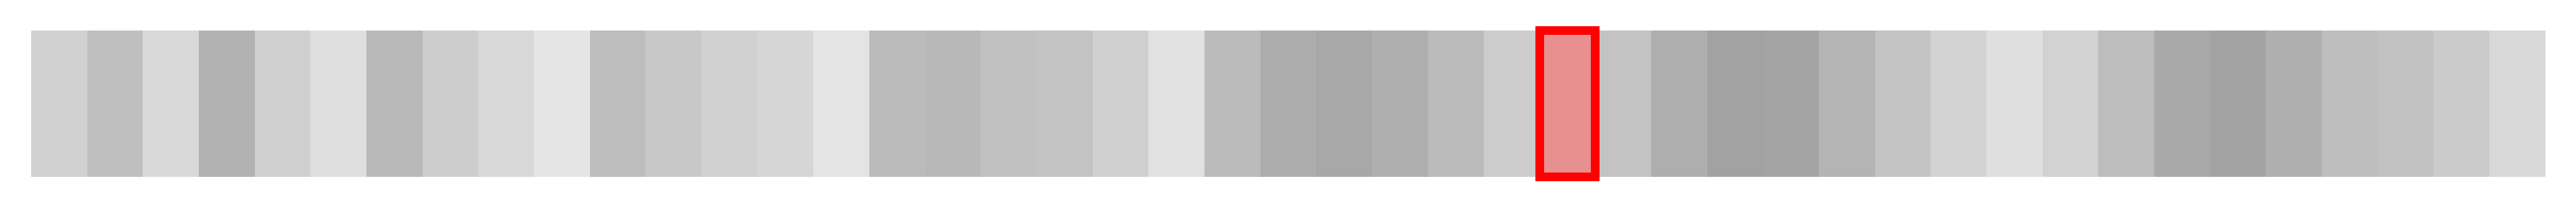

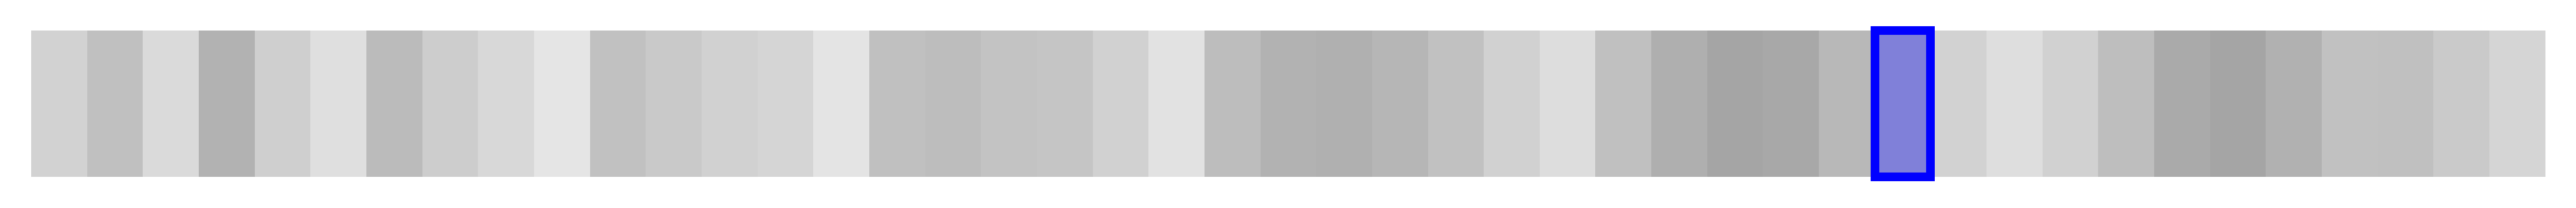

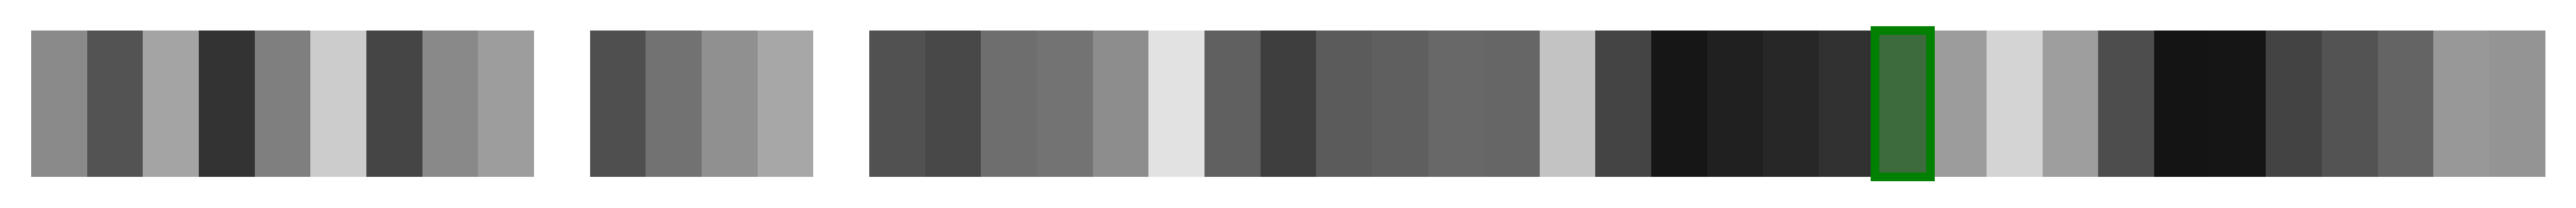

array([0.27288867, 0.1650159 , 0.32479677, 0.10259833, 0.25193179,
       0.40427035, 0.13800624, 0.27136557, 0.31151934, 0.50542451,
       0.15780026, 0.22675714, 0.28622576, 0.33081084, 0.50425241,
       0.16055476, 0.14269885, 0.21751154, 0.22775076, 0.28016732,
       0.44727585, 0.19080878, 0.12285459, 0.18067289, 0.18842397,
       0.20692141, 0.20276357, 0.38657993, 0.1345704 , 0.04452537,
       0.06460355, 0.0784704 , 0.09858999, 0.18975765, 0.30807971,
       0.42037894, 0.31216234, 0.15371852, 0.04097506, 0.04203911,
       0.13372967, 0.16554309, 0.19833459, 0.3011893 , 0.29347899])

In [61]:
# ---- tweakable ----
barcode_width_per_entry = 0.18  # figure-width scaling per off-diag entry


def plot_barcode(spi, *, cmap="gray", vmin=None, vmax=None, center=None,
                 highlight=None, highlight_color="red", highlight_lw=2.0,
                 highlight_alpha=0.35):
    """1D 'barcode' of one SPI's symmetrised lower-tri off-diagonals (loaded from ARCHIVE).

    highlight: cell pair(s) to mark. None -> none; a single (i, j) tuple uses
               highlight_color; a dict {(i, j): color} sets a color per pair.
               Each entry gets a translucent fill (highlight_alpha) + solid border.
               Order-insensitive: (i, j) and (j, i) map to the same barcode entry.
    """
    if highlight is None:
        highlight = {}
    elif isinstance(highlight, tuple):
        highlight = {highlight: highlight_color}

    with np.load(ARCHIVE) as npz:
        mat = np.asarray(npz[spi], float)
    sym = 0.5 * (mat + mat.T)
    lower = np.tril(np.ones(sym.shape, bool), k=-1)
    vec = sym[lower]
    pos = np.full(sym.shape, -1, int)  # (row, col) with row>col -> index into vec
    pos[lower] = np.arange(vec.size)
    width = max(1, vec.size * barcode_width_per_entry)
    fig, ax = plt.subplots(figsize=(width, 0.5), dpi=dpi)
    sns.heatmap(vec[np.newaxis, :], cmap=cmap, vmin=vmin, vmax=vmax, center=center,
                cbar=False, xticklabels=False, yticklabels=False, ax=ax)
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    for (i, j), c in highlight.items():
        a, b = max(i, j), min(i, j)
        if a == b or a >= sym.shape[0] or b < 0:
            continue  # diagonal / out of range
        ax.add_patch(plt.Rectangle((pos[a, b], 0), 1, 1, facecolor=mpl.colors.to_rgba(c, highlight_alpha),
                                   edgecolor=c, lw=highlight_lw, clip_on=False, zorder=5))
    fig.tight_layout(pad=0.05)
    fig.savefig(output_dir / f"barcode_{spi}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return vec


# plot_barcode("cov_EmpiricalCovariance", cmap="gray", vmin=-1.0, vmax=1.0, center=0.0)
# plot_barcode("spearmanr", cmap="gray", vmin=-1.0, vmax=1.0, center=0.0)
# plot_barcode("mi_kraskov_NN-4", cmap="gray")

# highlight the (i,j)=(2,8) entry red:
plot_barcode("cov_EmpiricalCovariance", cmap="gray", vmin=-1.0, vmax=1.0, center=0.0, highlight={(7, 6): "red"})
plot_barcode("spearmanr", cmap="gray", vmin=-1.0, vmax=1.0, center=0.0, highlight={(8, 5): "blue"})
plot_barcode("mi_kraskov_NN-4", cmap="gray", vmin=0, vmax=None, center=None, highlight={(8, 5): "green"})

## Two SPIs against each other (SPI-SPI space)

Symmetrises each matrix and uses the upper triangle. Set `spi_x` / `spi_y` to any pair from `spi_mpis.npz`.

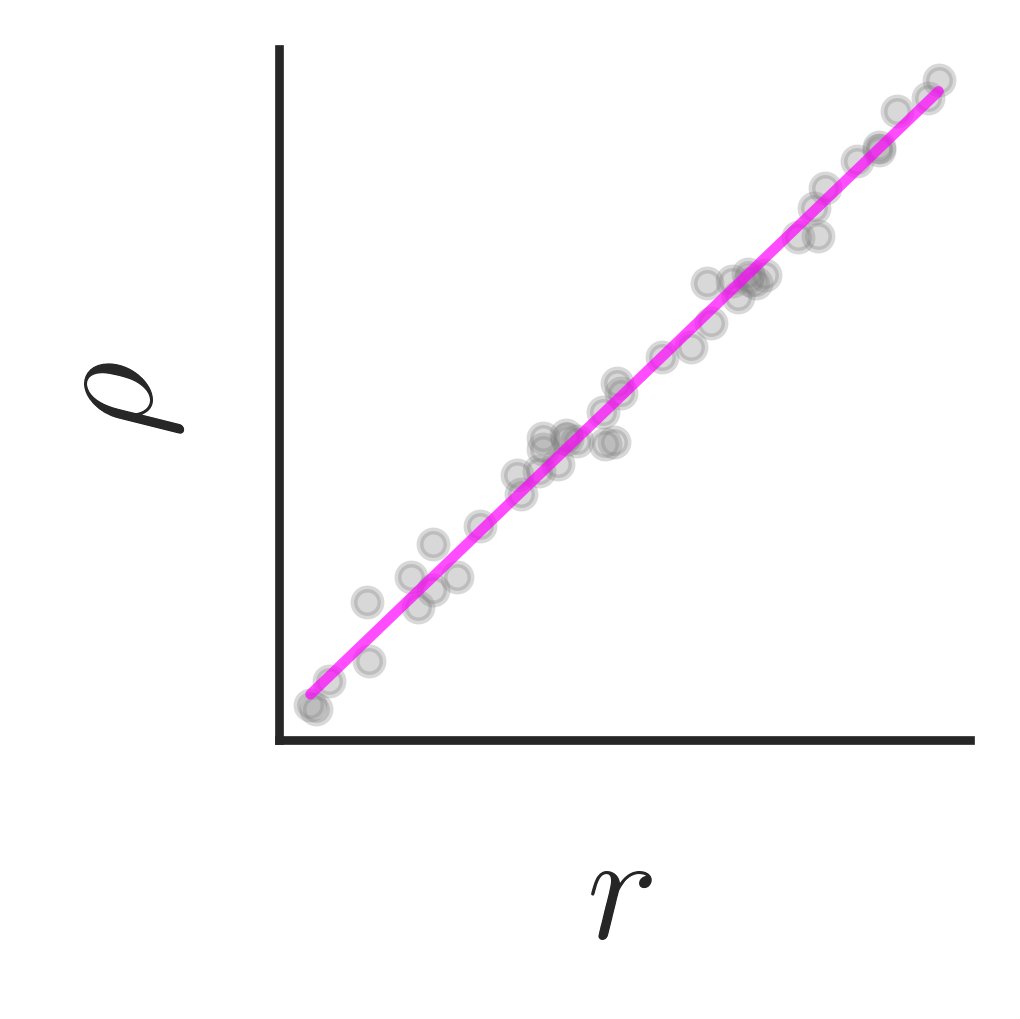

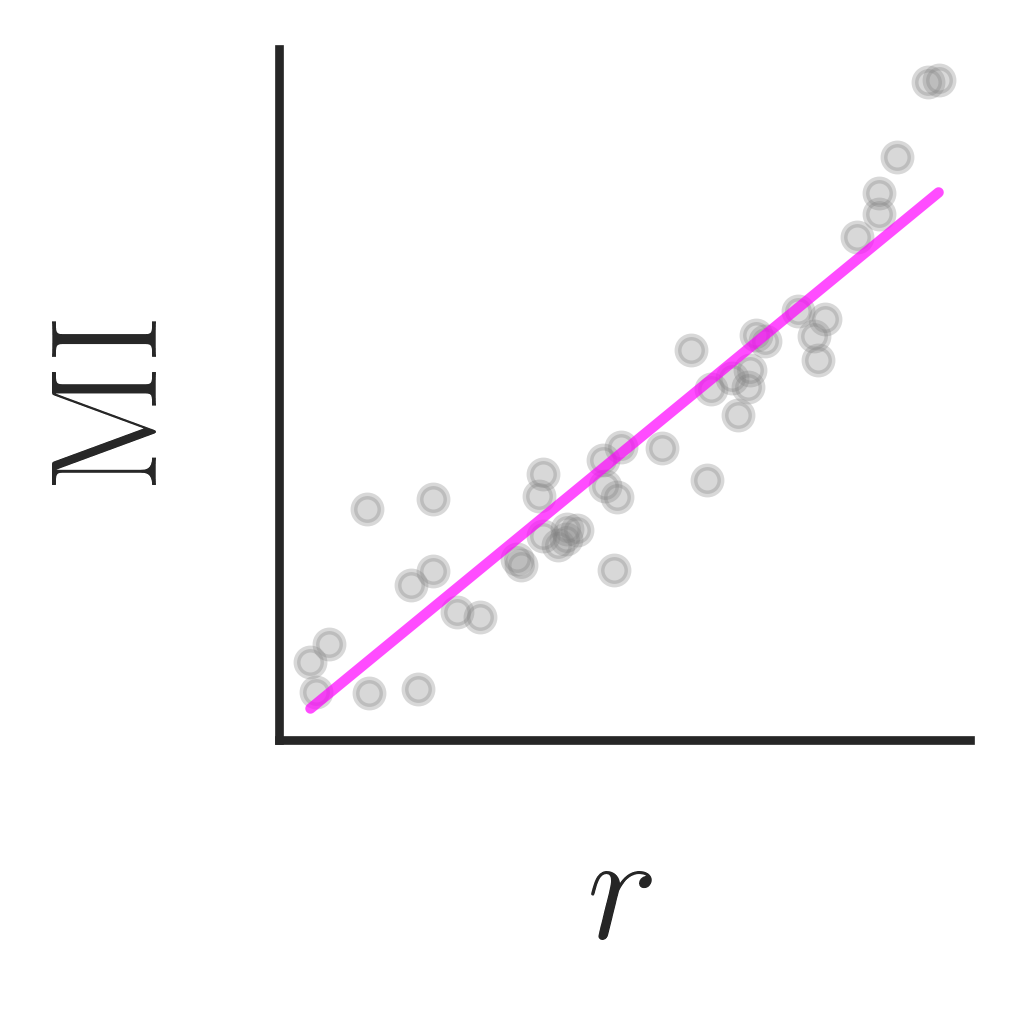

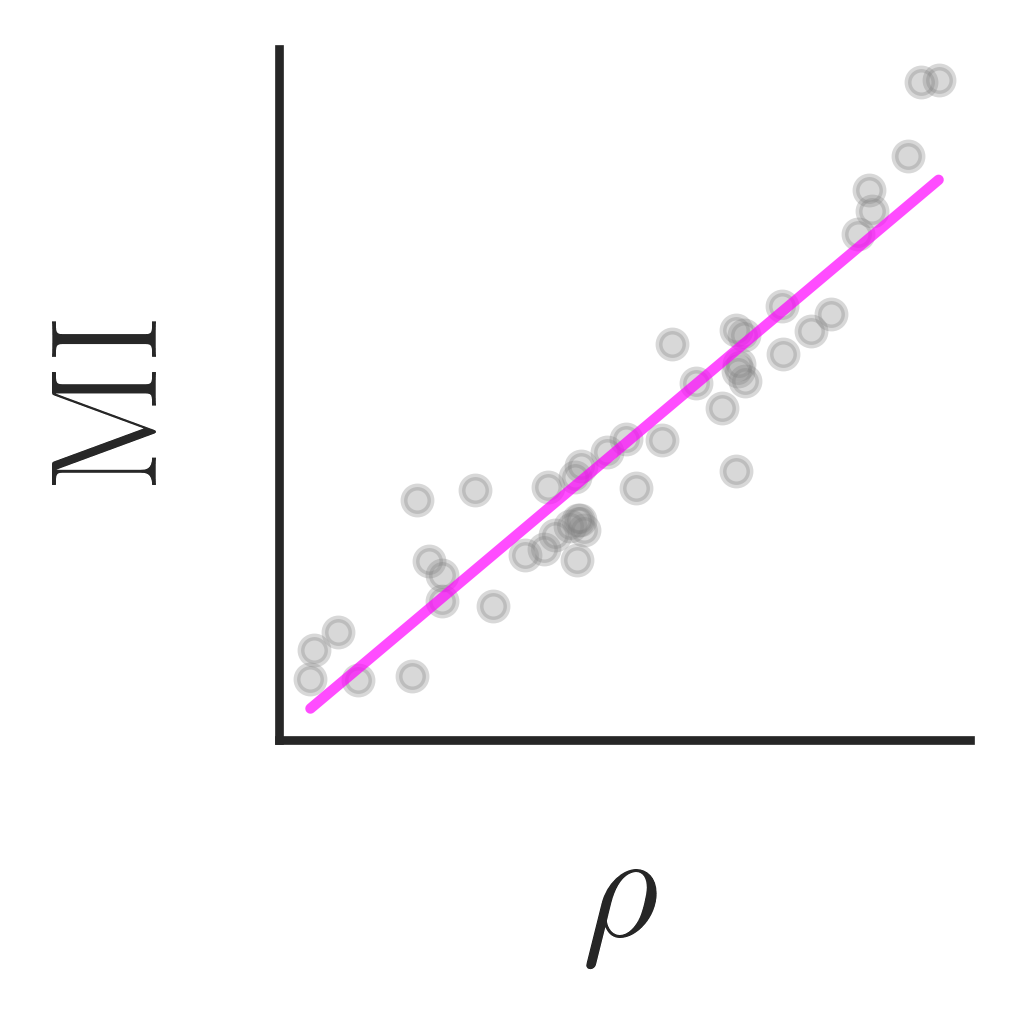

In [56]:
def plot_spi_spi_scatter(spi_x, spi_y, label_x=None, label_y=None, x_lim=None, y_lim=None,
                         dpi=dpi, figsize=(2.5,2.5), label=label):
    with np.load(ARCHIVE) as npz:
        A = np.asarray(npz[spi_x], float)
        B = np.asarray(npz[spi_y], float)
    A = 0.5 * (A + A.T)
    B = 0.5 * (B + B.T)
    mask = np.triu(np.ones(A.shape, bool), k=1)
    x_vals = A[mask]; y_vals = B[mask]
    finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_vals = x_vals[finite]; y_vals = y_vals[finite]

    r = float(np.corrcoef(x_vals, y_vals)[0, 1])

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.scatter(x_vals, y_vals, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
    sns.regplot(x=x_vals, y=y_vals, ax=ax, scatter=False, line_kws={'linewidth': 1.5, 'color': reg_color, 'alpha': 0.7}, ci=None)
    xl = label_x or spi_x.replace("_", r"\_") if use_latex else spi_x
    yl = label_y or spi_y.replace("_", r"\_") if use_latex else spi_y
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if x_lim is not None:
        ax.set_xlim(*x_lim)
    if y_lim is not None:
        ax.set_ylim(*y_lim)
    if label == True:
        ax.text(
            0.03, 0.97,
            f"$r = {r:.2f}$",
            transform=ax.transAxes, ha="left", va="top",
        )
    ax.set_box_aspect(1) 
    fig.tight_layout()
    fig.savefig(output_dir / f"spi_space_{spi_x}_vs_{spi_y}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()

# ---- tweakable ----
spi_x = "mi_kraskov_NN-4"; label_x = r"$\mathrm{MI}$"
spi_y = "cov_EmpiricalCovariance"; label_y = r"$r$"
scatter_color = "grey"
reg_color = "magenta"
scatter_s = 15
scatter_alpha = 0.3
label = False

plot_spi_spi_scatter("cov_EmpiricalCovariance", "spearmanr", label_x=r"$r$", label_y=r"$\rho$", 
                    # x_lim=(-1.0, 1.0), y_lim=(-1.0, 1.0), 
                    label=label)
plot_spi_spi_scatter("cov_EmpiricalCovariance", "mi_kraskov_NN-4", label_x=r"$r$", label_y=r"$\mathrm{MI}$", 
                    # x_lim=(-1.0, 1.0), y_lim=None, 
                    label=label)
plot_spi_spi_scatter("spearmanr", "mi_kraskov_NN-4", label_x=r"$\rho$", label_y=r"$\mathrm{MI}$", 
                    # x_lim=(-1.0, 1.0), y_lim=None, 
                    label=label)

##### Feature matrix

In [ ]:
# make this into the feature matrix heatmap: features/data-embeddings-proof_benchmarked_260505_pearson.npz
# Can show where each of the 3 SPI-SPI features are in the {K \choose 2}-dimensional feature matrix space.

##### LaTeX maker (if Inkscape bugs)

In [79]:
# ---- LaTeX maker: render a standalone math expression as a tight transparent figure ----
# under usetex: amssymb -> \mathbb etc.; mathtools -> \coloneqq etc.
if use_latex:
    mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{mathtools}"


def plot_latex(expr, *, name="latex", fontsize=None, color="black",
               figsize=(1, 1), pad=0.02, dpi=dpi):
    """Render a single math expression as a tight, transparent figure.

    expr: full text incl. the surrounding $...$, e.g. r"$\\in \\mathbb{R}^{M \\times M}$".
    name: filename stem -> latex_<name>.<save_fmt> in output_dir.
    fontsize: None -> inherit the theme font.size from the setup cell.
    """
    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.text(0.5, 0.5, rf"{expr}", ha="center", va="center",
             fontsize=fontsize, color=color)
    fig.savefig(output_dir / f"latex_{name}.{save_fmt}", dpi=dpi,
                bbox_inches="tight", pad_inches=pad, transparent=True)
    plt.show()


# plot_latex(r"$\in \mathbb{R}^{M \times M}$", name="rMM")
plot_latex(r"$\Rightarrow$", name="Rarrow")
# plot_latex(r"$X_t^{(i)}$", name="Xti")
# plot_latex(r"$\rho$", name="rho", fontsize=64)

<Figure size 500x500 with 0 Axes>